# Regresión Lineal: Coste de un incidente de seguridad

En este ejercicio se explican los fundamentos básicos de la regresión lineal aplicada a un caso de uso sencillo relacionado con la Ciberseguridad.

## Enunciado del ejercicio

El ejercicio consiste en predecir el coste de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.

### 0. Imports

# Instalacion de librerías externas
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn

### 1. Generación del conjunto de datos

In [3]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

print("La longitud del conjunto de datos es:", len(X))

La longitud del conjunto de datos es: 100


### 2. Visualización del conjunto de datos

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

# las imagenes aparecen dentro del Notebook

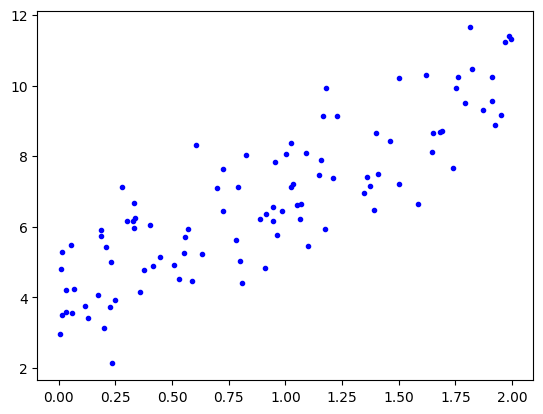

In [5]:
plt.plot(X, y, "b.")
plt.show()

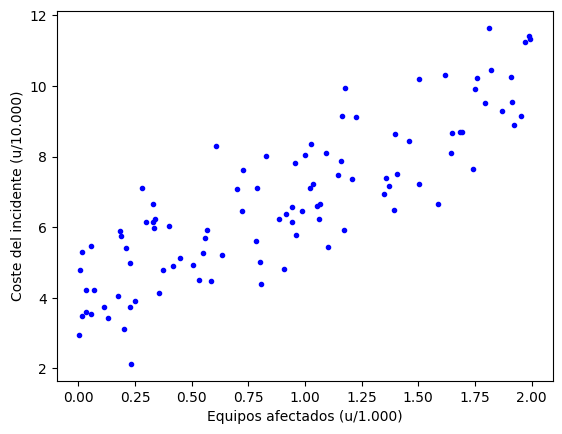

In [6]:
plt.plot(X, y, "b.")
plt.xlabel("Equipos afectados (u/1.000)")
plt.ylabel("Coste del incidente (u/10.000)")
plt.show()

### 3. Modificación del conjunto de datos

In [7]:
import pandas as pd

In [8]:
# Convertimos nuestro conjunto de datos en un diccionario
data = {'n_equipos_afectados': X.flatten(), 'coste': y.flatten()}

# Se construye el DataFrame
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,coste
0,0.129138,3.429078
1,0.827054,8.021742
2,0.186581,5.746786
3,0.200462,3.131606
4,1.051472,6.614678
5,1.101037,5.453216
6,0.015061,5.289001
7,0.885845,6.220727
8,1.923718,8.891811
9,0.004831,2.961333


In [9]:
# Escalado del número de equipos afectados
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')

# Escalado del coste
df['coste'] = df['coste'] * 10000
df['coste'] = df['coste'].astype('int')
df.head(10)

,n_equipos_afectados,coste
0,129,34290
1,827,80217
2,186,57467
3,200,31316
4,1051,66146
5,1101,54532
6,15,52890
7,885,62207
8,1923,88918
9,4,29613


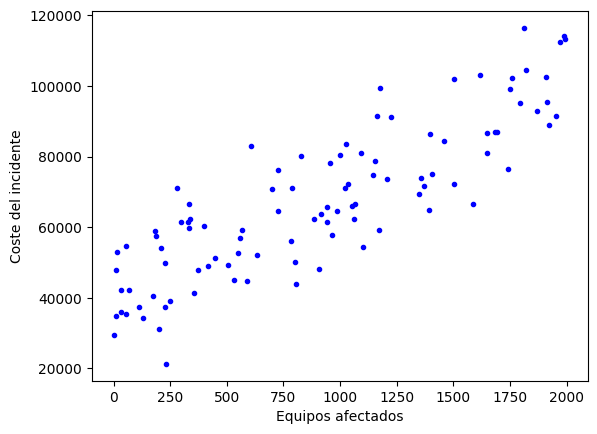

In [10]:
# Representación gráfica del conjunto de datos
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 4. Construcción del modelo

Entrenamos nuestro algoritmo de Regresión Lieal

Algorítmo basado en **Aprendizaje Supervisado**

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
# Construcción del modelo y ajuste de la función hipótesis
# La función fit() va a ser equivalente a entrenar
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1, 1), df['coste'].values)

LinearRegression()

In [13]:
# Parámetro theta 0
lin_reg.intercept_
print(lin_reg.intercept_)

39971.651121558476


In [14]:
# Parámetro theta 1
lin_reg.coef_
print(lin_reg.coef_)

[30.28350919]


In [15]:
# Predicción para el valor mínimo y máximo del conjunto de datos de entrenamiento
X_min_max = np.array([[df["n_equipos_afectados"].min()], [df["n_equipos_afectados"].max()]])
y_train_pred = lin_reg.predict(X_min_max)

In [16]:
print(min(X*1000), max(X*1000))
print(y_train_pred)

[4.83119401] [1994.37651806]
[ 40092.78515832 100356.96844579]


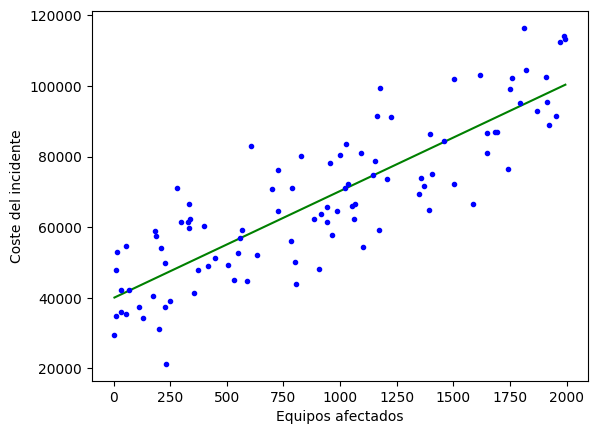

In [17]:
# Representación gráfica de la función hipótesis generada
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 5. Predicción de nuevos ejemplos

In [18]:
x_new = np.array([[1300]]) # 1300 equipos afectados

# Predicción del coste que tendría el incidente
coste = lin_reg.predict(x_new) 

print("El coste del incidente sería:", int(coste[0]), "$")

El coste del incidente sería: 79340 $


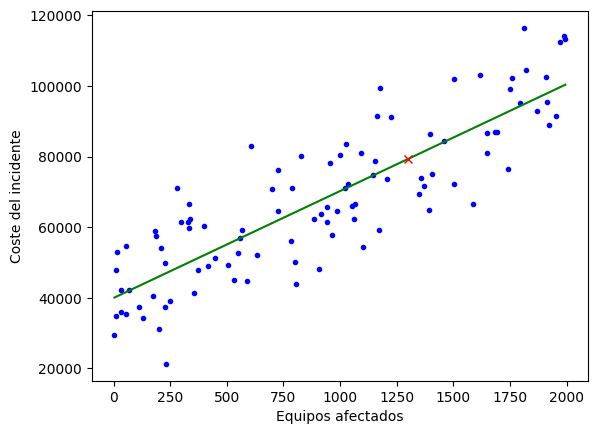

In [19]:
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

## 6. Descenso de gradiente

Ahora estimaremos la misma recta de regresión, pero sin utilizar `LinearRegression` para el ajuste.

El modelo sigue siendo

$$
\hat{y}=\beta_0+\beta_1x.
$$

Para evitar problemas numéricos debidos a la escala de `n_equipos_afectados`, primero estandarizamos únicamente la variable $x$:

$$
z=\frac{x-\bar{x}}{s_x}.
$$

El descenso de gradiente repetirá cuatro pasos:

1. calcular predicciones;
2. calcular residuos;
3. calcular los gradientes del MSE;
4. actualizar $\beta_0$ y $\beta_1$.


In [20]:
# Datos que ya fueron usados por Scikit-Learn
x = df["n_equipos_afectados"].to_numpy(dtype=float)
y_real = df["coste"].to_numpy(dtype=float)

# Estandarizamos x para que el descenso de gradiente sea estable
media_x = x.mean()
desv_x = x.std()

z = (x - media_x) / desv_x

# Valores iniciales
beta0_std = 0.0
beta1_std = 0.0

eta = 0.01          # tasa de aprendizaje
epocas = 2000
costos = []

for epoca in range(epocas):
    # 1. Predicción
    y_hat = beta0_std + beta1_std * z

    # 2. Residuos
    errores = y_real - y_hat

    # Guardamos el MSE
    mse = np.mean(errores ** 2)
    costos.append(mse)

    # 3. Gradientes del MSE
    grad_b0 = -2 * np.mean(errores)
    grad_b1 = -2 * np.mean(errores * z)

    # 4. Actualización de parámetros
    beta0_std -= eta * grad_b0
    beta1_std -= eta * grad_b1

print("Parámetros obtenidos sobre x estandarizada:")
print("beta0* =", beta0_std)
print("beta1* =", beta1_std)


Parámetros obtenidos sobre x estandarizada:
beta0* = 67532.36999999965
beta1* = 18288.666321683668


### Volver a la escala original de $x$

Como el descenso de gradiente se realizó usando la variable estandarizada $z$, convertimos los coeficientes a la escala original de número de equipos.

Si

$$
\hat y=\beta_0^*+\beta_1^*z,
\qquad
z=\frac{x-\bar{x}}{s_x},
$$

entonces

$$
\hat y=
\left(\beta_0^*-\beta_1^*\frac{\bar{x}}{s_x}\right)
+
\left(\frac{\beta_1^*}{s_x}\right)x.
$$


In [21]:
# Coeficientes del descenso de gradiente en la escala original
beta1_gd = beta1_std / desv_x
beta0_gd = beta0_std - beta1_std * media_x / desv_x

print("Parámetros del descenso de gradiente en la escala original:")
print(f"beta0 = {beta0_gd:.6f}")
print(f"beta1 = {beta1_gd:.6f}")


Parámetros del descenso de gradiente en la escala original:
beta0 = 39971.651122
beta1 = 30.283509


## 7. Curva de aprendizaje del descenso de gradiente

La siguiente gráfica muestra cómo cambia el MSE a medida que avanzan las épocas.

Una disminución rápida seguida de una estabilización indica que el algoritmo está convergiendo.


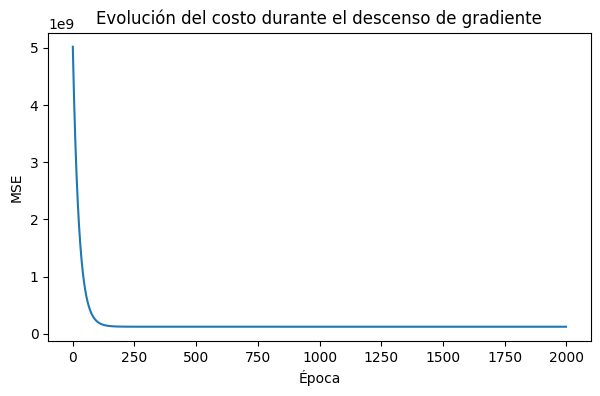

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(costos)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del costo durante el descenso de gradiente")
plt.show()


## 8. Comparación: Scikit-Learn vs. descenso de gradiente

Ahora comparamos los parámetros estimados por ambos métodos.

- **Scikit-Learn** ajusta directamente el modelo lineal mediante procedimientos numéricos optimizados.
- **Descenso de gradiente** llega a la solución de forma iterativa, reduciendo el MSE época tras época.

Si el descenso de gradiente convergió correctamente, los valores de $\beta_0$ y $\beta_1$ deberían ser prácticamente iguales.


In [23]:
# Parámetros de Scikit-Learn
beta0_sklearn = float(lin_reg.intercept_)
beta1_sklearn = float(lin_reg.coef_[0])

comparacion = pd.DataFrame({
    "Método": ["Scikit-Learn", "Descenso de gradiente"],
    "beta0 (intercepto)": [beta0_sklearn, beta0_gd],
    "beta1 (pendiente)": [beta1_sklearn, beta1_gd]
})

display(comparacion.round(6))

print("Diferencia absoluta en beta0:",
      abs(beta0_sklearn - beta0_gd))

print("Diferencia absoluta en beta1:",
      abs(beta1_sklearn - beta1_gd))


,Método,beta0 (intercepto),beta1 (pendiente)
0,Scikit-Learn,39971.651122,30.283509
1,Descenso de gradiente,39971.651122,30.283509


Diferencia absoluta en beta0: 2.1100277081131935e-10
Diferencia absoluta en beta1: 1.4921397450962104e-13


In [24]:
# Comparamos también el error de ambos modelos
y_pred_sklearn = lin_reg.predict(x.reshape(-1, 1))
y_pred_gd = beta0_gd + beta1_gd * x

mse_sklearn = np.mean((y_real - y_pred_sklearn) ** 2)
mse_gd = np.mean((y_real - y_pred_gd) ** 2)

print(f"MSE Scikit-Learn:        {mse_sklearn:.4f}")
print(f"MSE Descenso gradiente:  {mse_gd:.4f}")


MSE Scikit-Learn:        123423497.9072
MSE Descenso gradiente:  123423497.9072


### Pequeño análisis de los parámetros

El parámetro $\beta_0$ es el **intercepto** de la recta. Representa el coste que el modelo estimaría cuando el número de equipos afectados es cero. Como el conjunto de datos puede no contener observaciones cercanas a cero, este parámetro debe interpretarse con precaución.

El parámetro $\beta_1$ es la **pendiente**. En este problema representa aproximadamente cuánto aumenta el coste esperado del incidente cuando se añade **un equipo afectado adicional**.

Los dos métodos deberían producir parámetros casi idénticos. Una diferencia muy pequeña se debe únicamente a que el descenso de gradiente es un procedimiento iterativo y se detiene después de un número finito de épocas.

Podemos generar automáticamente una interpretación usando los valores obtenidos en la ejecución:


In [25]:
print(f"Scikit-Learn estima beta0 = {beta0_sklearn:.2f}")
print(f"Scikit-Learn estima beta1 = {beta1_sklearn:.4f}")
print()
print(f"Descenso de gradiente estima beta0 = {beta0_gd:.2f}")
print(f"Descenso de gradiente estima beta1 = {beta1_gd:.4f}")
print()

print(
    f"Interpretación de beta1: por cada equipo afectado adicional, "
    f"el coste esperado aumenta aproximadamente en ${beta1_sklearn:.2f}."
)

if abs(beta0_sklearn - beta0_gd) < 0.1 and abs(beta1_sklearn - beta1_gd) < 0.001:
    print(
        "Conclusión: ambos métodos llegaron prácticamente a la misma recta de regresión."
    )
else:
    print(
        "Los parámetros todavía presentan diferencias. "
        "Puede ser conveniente aumentar el número de épocas o revisar eta."
    )


Scikit-Learn estima beta0 = 39971.65
Scikit-Learn estima beta1 = 30.2835

Descenso de gradiente estima beta0 = 39971.65
Descenso de gradiente estima beta1 = 30.2835

Interpretación de beta1: por cada equipo afectado adicional, el coste esperado aumenta aproximadamente en $30.28.
Conclusión: ambos métodos llegaron prácticamente a la misma recta de regresión.


## 9. Visualización de residuos

Los residuos se calculan como

$$
e_i=y_i-\hat y_i.
$$

En un ajuste lineal razonable deberían aparecer dispersos alrededor de cero, sin un patrón sistemático claramente visible.


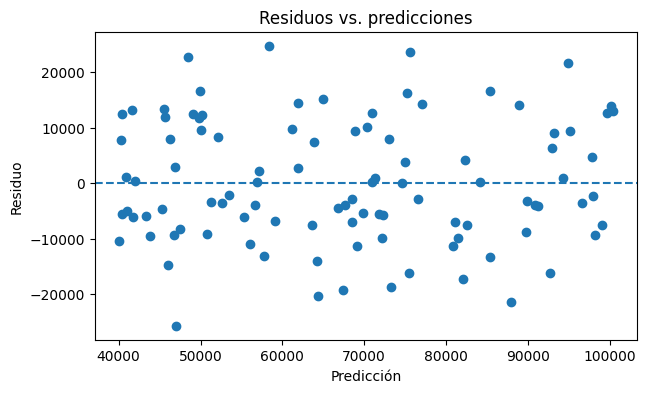

In [26]:
residuos = y_real - y_pred_sklearn

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_sklearn, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos vs. predicciones")
plt.show()


### ¿Qué observar en la gráfica de residuos?

- Una nube aproximadamente aleatoria alrededor de cero es una buena señal para un modelo lineal básico.
- Una **curvatura** puede sugerir que la relación entre las variables no es completamente lineal.
- Una forma de **embudo** puede indicar que la variabilidad de los errores cambia con el nivel de la predicción.
- Residuos muy alejados del resto pueden sugerir observaciones atípicas.

Esta gráfica no demuestra por sí sola que el modelo sea correcto, pero es una herramienta sencilla para detectar posibles problemas de ajuste.


# 10. Regresión lineal múltiple

En la regresión lineal simple usamos **una sola variable explicativa**:

$$
\hat y=\beta_0+\beta_1x.
$$

En la **regresión lineal múltiple** utilizamos dos o más variables:

$$
\hat y=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p.
$$

La idea más importante para interpretar un coeficiente es:

> $\beta_j$ representa el cambio esperado en la predicción cuando $x_j$ aumenta una unidad, **manteniendo constantes las demás variables**.


## Ejemplo: precio de viviendas

Supongamos que queremos estimar el precio de una vivienda usando:

- `area`: superficie en m²;
- `habitaciones`: número de habitaciones.

Usaremos un conjunto pequeño solamente para entender el procedimiento.


In [27]:
datos = pd.DataFrame({
    "area": [40, 55, 60, 75, 90, 110, 120, 135],
    "habitaciones": [1, 2, 2, 3, 3, 4, 4, 5],
    "precio": [160, 210, 230, 280, 330, 390, 420, 470]
})

datos


,area,habitaciones,precio
0,40,1,160
1,55,2,210
2,60,2,230
3,75,3,280
4,90,3,330
5,110,4,390
6,120,4,420
7,135,5,470


In [28]:
# Variables explicativas y variable respuesta
X = datos[["area", "habitaciones"]]
y = datos["precio"]

# Ajustamos el modelo
modelo_multiple = LinearRegression()
modelo_multiple.fit(X, y)

print("Intercepto:", round(modelo_multiple.intercept_, 3))

for variable, coeficiente in zip(X.columns, modelo_multiple.coef_):
    print(variable, ":", round(coeficiente, 3))


Intercepto: 34.865
area : 3.081
habitaciones : 4.189


### Interpretación de los coeficientes

Si el modelo obtenido tiene la forma

$$
\widehat{precio}
=
\hat\beta_0+
\hat\beta_1(area)+
\hat\beta_2(habitaciones),
$$

entonces:

- $\hat\beta_1$ indica cuánto cambia el **precio estimado** por cada m² adicional, manteniendo fijo el número de habitaciones.
- $\hat\beta_2$ indica cuánto cambia el **precio estimado** por una habitación adicional, manteniendo fija el área.

Los coeficientes describen **asociaciones dentro del modelo**; por sí solos no demuestran causalidad.


## Predicción con varias variables

Para predecir una vivienda nueva debemos proporcionar un valor para **cada predictor utilizado durante el entrenamiento**.


In [29]:
vivienda_nueva = pd.DataFrame({
    "area": [200],
    "habitaciones": [3]
})

precio_estimado = modelo_multiple.predict(vivienda_nueva)

print("Precio estimado:", round(precio_estimado[0], 2))


Precio estimado: 663.65


## Evaluación del modelo múltiple

Además de interpretar los coeficientes, podemos estudiar:

- **MSE:** error cuadrático medio;
- **RMSE:** error típico en las mismas unidades de $y$;
- **$R^2$:** proporción de variabilidad explicada por el modelo;
- **residuos:** diferencias entre valores observados y predichos.


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_multiple = modelo_multiple.predict(X)

mse_multiple = mean_squared_error(y, y_pred_multiple)
rmse_multiple = mse_multiple ** 0.5
r2_multiple = r2_score(y, y_pred_multiple)

print("MSE:", round(mse_multiple, 3))
print("RMSE:", round(rmse_multiple, 3))
print("R²:", round(r2_multiple, 3))


MSE: 6.419
RMSE: 2.534
R²: 0.999


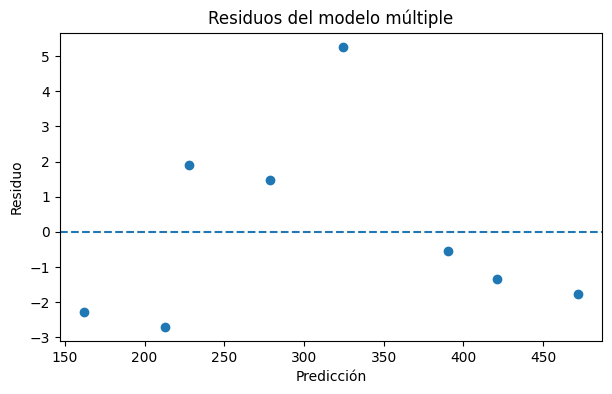

In [31]:
residuos_multiple = y - y_pred_multiple

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_multiple, residuos_multiple)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos del modelo múltiple")
plt.show()


## Regresión múltiple con una variable categórica

Una variable categórica debe convertirse en variables indicadoras o **dummies**.

Por ejemplo, si `zona` tiene las categorías `Norte`, `Centro` y `Sur`, podemos tomar `Norte` como categoría de referencia. Los coeficientes de las otras zonas se interpretan como diferencias respecto a `Norte`, manteniendo constantes las demás variables.


In [32]:
datos_zona = pd.DataFrame({
    "area": [70, 80, 90, 100, 110, 120, 85, 105, 125],
    "habitaciones": [2, 2, 3, 3, 4, 4, 3, 3, 4],
    "zona": ["Norte", "Centro", "Sur",
             "Norte", "Centro", "Sur",
             "Norte", "Centro", "Sur"],
    "precio": [300, 350, 315, 390, 455, 405, 345, 435, 430]
})

datos_zona


,area,habitaciones,zona,precio
0,70,2,Norte,300
1,80,2,Centro,350
2,90,3,Sur,315
3,100,3,Norte,390
4,110,4,Centro,455
5,120,4,Sur,405
6,85,3,Norte,345
7,105,3,Centro,435
8,125,4,Sur,430


In [33]:
# drop_first=True deja una categoría como referencia
datos_dummies = pd.get_dummies(
    datos_zona,
    columns=["zona"],
    drop_first=True,
    dtype=int
)

datos_dummies


,area,habitaciones,precio,zona_Norte,zona_Sur
0,70,2,300,1,0
1,80,2,350,0,0
2,90,3,315,0,1
3,100,3,390,1,0
4,110,4,455,0,0
5,120,4,405,0,1
6,85,3,345,1,0
7,105,3,435,0,0
8,125,4,430,0,1


In [34]:
X = datos_dummies.drop(columns="precio")
y = datos_dummies["precio"]

modelo_zona = LinearRegression()
modelo_zona.fit(X, y)

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_zona.coef_
})

print("Intercepto:", round(modelo_zona.intercept_, 3))
display(coeficientes.round(3))


Intercepto: 100.921


,Variable,Coeficiente
0,area,3.024
1,habitaciones,5.024
2,zona_Norte,-26.341
3,zona_Sur,-73.667


### ¿Cómo se interpreta una dummy?

Si `Norte` quedó como categoría de referencia y aparece, por ejemplo, un coeficiente para `zona_Sur`, ese coeficiente representa la diferencia esperada entre una vivienda del **Sur** y una vivienda comparable del **Norte**, manteniendo constantes el área y el número de habitaciones.


# 11. $R^2$, $R^2$ ajustado y AIC

En regresión múltiple debemos tener cuidado con $R^2$: al agregar predictores, el $R^2$ de entrenamiento normalmente no disminuye.

Por ello también resulta útil revisar:

$$
R^2_{\mathrm{ajustado}}
=
1-(1-R^2)\frac{n-1}{n-p-1},
$$

que penaliza parcialmente el uso de predictores innecesarios.

El **AIC** compara modelos equilibrando ajuste y complejidad:

$$
AIC=2k-2\log(\hat L).
$$

Entre modelos ajustados sobre **los mismos datos y la misma variable respuesta**, un AIC menor indica un mejor equilibrio relativo entre ajuste y complejidad.


In [35]:
import statsmodels.formula.api as smf

modelo_sm_simple = smf.ols(
    "precio ~ area",
    data=datos
).fit()

modelo_sm_multiple = smf.ols(
    "precio ~ area + habitaciones",
    data=datos
).fit()

comparacion_modelos = pd.DataFrame({
    "Modelo": ["Simple: área", "Múltiple: área + habitaciones"],
    "R²": [modelo_sm_simple.rsquared,
           modelo_sm_multiple.rsquared],
    "R² ajustado": [modelo_sm_simple.rsquared_adj,
                    modelo_sm_multiple.rsquared_adj],
    "AIC": [modelo_sm_simple.aic,
            modelo_sm_multiple.aic]
})

comparacion_modelos.round(3)


,Modelo,R²,R² ajustado,AIC
0,Simple: área,0.999,0.999,42.611
1,Múltiple: área + habitaciones,0.999,0.999,43.577


### Lectura

No debemos escoger un modelo utilizando una sola métrica:

- **MSE/RMSE** ayudan a evaluar el tamaño de los errores.
- **$R^2$** resume la variabilidad explicada.
- **$R^2$ ajustado** considera también el número de predictores.
- **AIC** compara ajuste y complejidad entre modelos estadísticos candidatos.
- El gráfico de **residuos** ayuda a detectar patrones que el modelo lineal no está capturando.


# 12. Actividad 

## Datos: Diabetes de Scikit-Learn

Trabajaremos con el conjunto de datos `load_diabetes`, incluido en Scikit-Learn. Contiene mediciones de pacientes y una variable cuantitativa que representa la progresión de la enfermedad un año después.

Para esta actividad utilizaremos:

- `bmi`: índice de masa corporal;
- `bp`: presión arterial promedio;
- `s5`: una medición sanguínea;
- `target`: respuesta cuantitativa.

La actividad busca aplicar **regresión lineal simple y múltiple**, interpretación de coeficientes, predicción, residuos, MSE, RMSE, $R^2$, $R^2$ ajustado y AIC. No utilizaremos regularización.


In [36]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

df_diabetes = diabetes.frame[["bmi", "bp", "s5", "target"]].copy()

df_diabetes.head()


,bmi,bp,s5,target
0,0.061696,0.021872,0.019907,151.0
1,-0.051474,-0.026328,-0.068332,75.0
2,0.044451,-0.005670,0.002861,141.0
3,-0.011595,-0.036656,0.022688,206.0
4,-0.036385,0.021872,-0.031988,135.0


## Parte A. Exploración inicial

1. Observe el tamaño de la base.
2. Revise si existen valores faltantes.
3. Obtenga estadísticas descriptivas.
4. Grafique `bmi` frente a `target`.

**Pregunta:** ¿parece existir una relación aproximadamente lineal entre ambas variables?


In [37]:
print("Dimensión:", df_diabetes.shape)
print("\nValores faltantes:")
print(df_diabetes.isna().sum())

df_diabetes.describe()


Dimensión: (442, 4)

Valores faltantes:
bmi       0
bp        0
s5        0
target    0
dtype: int64


,bmi,bp,s5,target
count,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.245564e-16,-4.797570e-17,9.293722e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-9.027530e-02,-1.123988e-01,-1.260971e-01,25.000000
25%,-3.422907e-02,-3.665608e-02,-3.324559e-02,87.000000
50%,-7.283766e-03,-5.670422e-03,-1.947171e-03,140.500000
75%,3.124802e-02,3.564379e-02,3.243232e-02,211.500000
max,1.705552e-01,1.320436e-01,1.335973e-01,346.000000


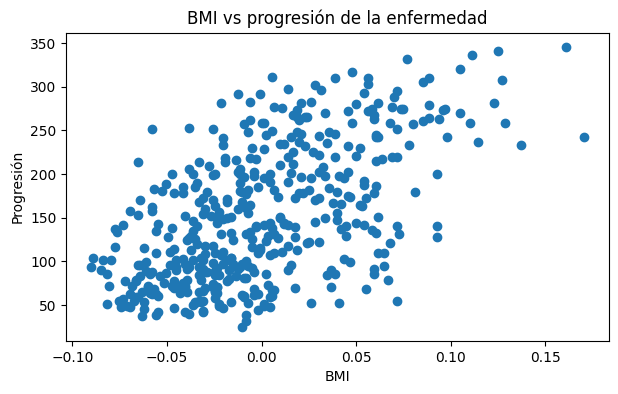

In [38]:
plt.figure(figsize=(7, 4))
plt.scatter(df_diabetes["bmi"], df_diabetes["target"])
plt.xlabel("BMI")
plt.ylabel("Progresión")
plt.title("BMI vs progresión de la enfermedad")
plt.show()


> **Respuesta:**  Podrias llegarse a considerar que la relacion podria llegarse ser lineal, pero observando mas detenidamente veo mucha variabilidad en la grafica por lo que podriamos considerarla con una tendencia lineal, o una tendencia en vase a una raiz por la variabilidad que tienen los datos. por lo que en este momento todavia no se puede asegurar su comportamiento lineal


## Parte B. Regresión lineal simple

Construya un modelo para predecir `target` utilizando solamente `bmi`.

Separe los datos en entrenamiento y prueba usando:

```python
test_size=0.25
random_state=42
```

Después:

1. ajuste el modelo;
2. interprete el intercepto y la pendiente;
3. calcule MSE, RMSE y $R^2$ en prueba;
4. grafique los residuos.


In [39]:
from sklearn.model_selection import train_test_split

X_simple = df_diabetes[["bmi"]]
y = df_diabetes["target"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y,
    test_size=0.25,
    random_state=42
)

modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)

pred_simple = modelo_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, pred_simple)
rmse_simple = mse_simple ** 0.5
r2_simple = r2_score(y_test_s, pred_simple)

print("Intercepto:", round(modelo_simple.intercept_, 3))
print("Coeficiente BMI:", round(modelo_simple.coef_[0], 3))
print("MSE:", round(mse_simple, 3))
print("RMSE:", round(rmse_simple, 3))
print("R² prueba:", round(r2_simple, 3))


Intercepto: 152.077
Coeficiente BMI: 975.277
MSE: 3775.617
RMSE: 61.446
R² prueba: 0.317


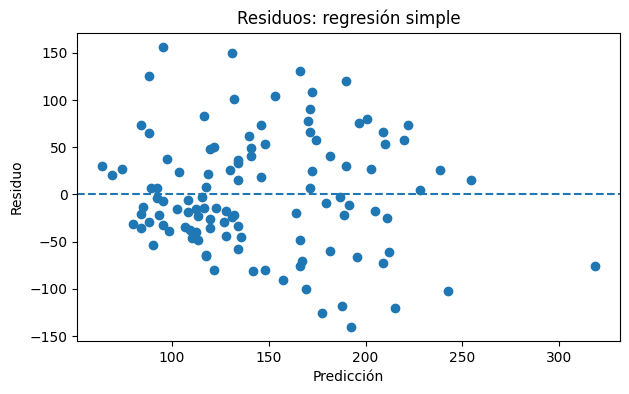

In [40]:
residuos_simple = y_test_s - pred_simple

plt.figure(figsize=(7, 4))
plt.scatter(pred_simple, residuos_simple)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos: regresión simple")
plt.show()


### Preguntas de interpretación

1. ¿El coeficiente de `bmi` es positivo o negativo?
2. ¿Cómo interpreta ese signo?
3. ¿Qué representa el RMSE?
4. ¿Los residuos parecen distribuirse sin un patrón sistemático evidente?
5. ¿Un $R^2$ alto demostraría causalidad? Justifique brevemente.


> #### Respuestas
> **1.** es positivo. siendo que Coeficiente ***BMI = 975.277***
> <br> **2.** aqui podemos dicernir que el signo se encuentra en un punto medio, no esta no sobreestimando y ni subestimando las variables de cada uno
> <br> **3.** ***RMSE*** representa la desviacion promedio entre los valores de la prueba y predicciones determidadas por el modelo, en este caso el lineal y con un valor de ***RMSE = 61.446***
> <br> **4.** Los residuos estan dispersos de forma aleatoria, alrededor de la linea del cero, por lo que sugiere que el modelo puede tener correlacion con un comportamiento lineal
> <br> **5.** En este caso el ***R²*** se usa para poder visualizar un grado cercano al modelo deseado, en este caso el modelo lineal. Tambien no estaria completo, ya que este utiliza una parte de los datos al momento de realizar este, por lo que tocaria rectificar si la otra prueba de R² es verosimil al resultado dado, en este caso ***0.317***

## Parte C. Regresión lineal múltiple

Ahora utilice simultáneamente:

- `bmi`;
- `bp`;
- `s5`.

Recuerde que cada coeficiente debe interpretarse **manteniendo constantes las demás variables**.


In [41]:
X_multiple = df_diabetes[["bmi", "bp", "s5"]]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y,
    test_size=0.25,
    random_state=42
)

modelo_multiple_real = LinearRegression()
modelo_multiple_real.fit(X_train_m, y_train_m)

pred_multiple = modelo_multiple_real.predict(X_test_m)

coeficientes_multiple = pd.DataFrame({
    "Variable": X_multiple.columns,
    "Coeficiente": modelo_multiple_real.coef_
})

print("Intercepto:", round(modelo_multiple_real.intercept_, 3))
display(coeficientes_multiple.round(3))


Intercepto: 151.636


,Variable,Coeficiente
0,bmi,642.784
1,bp,308.411
2,s5,468.811


In [42]:
mse_multiple_real = mean_squared_error(y_test_m, pred_multiple)
rmse_multiple_real = mse_multiple_real ** 0.5
r2_multiple_real = r2_score(y_test_m, pred_multiple)

print("MSE:", round(mse_multiple_real, 3))
print("RMSE:", round(rmse_multiple_real, 3))
print("R² prueba:", round(r2_multiple_real, 3))


MSE: 2752.235
RMSE: 52.462
R² prueba: 0.502


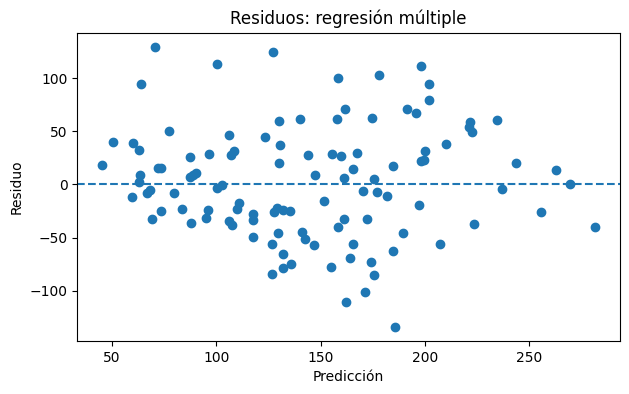

In [43]:
residuos_multiple_real = y_test_m - pred_multiple

plt.figure(figsize=(7, 4))
plt.scatter(pred_multiple, residuos_multiple_real)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos: regresión múltiple")
plt.show()


### Preguntas de interpretación

1. Interprete el coeficiente de `bmi` manteniendo constantes `bp` y `s5`.
2. Interprete el signo del coeficiente de `bp`.
3. ¿Qué modelo obtuvo menor RMSE en prueba: el simple o el múltiple?
4. ¿Qué modelo obtuvo mayor $R^2$ en prueba?
5. ¿Agregar predictores mejoró la capacidad predictiva en este caso?


> #### Respuestas
> **1.** se puede decir que ***bp*** y ***s5*** se vuelven variables dentro del sistema sugerido, volviendose **bo** y **b1** cada una correspondientemente para conectarlas a un modelo lineal
> <br> **2.** este seria positivo, equivaliendo un valor de ***bp = 308.411***. indicando que el promedio estaria incrementando.
> <br> **3.** en este caso el modelo multiple tuvo un valor menor, siendo este de ***RMSE = 52.462***
> <br> **4.** el modelo multiple vuelve a tener una diferencia mayor a comparacion con el modelo simple, siendo en este caso ***R² = 0.502***
> <br> **5.** Si agregaramos mas, podria disminuir el error cuadratio medio y por consiguiente aumentar la cantidad de la varianza explicada. siendo esto tomarlo con pinsas ya que comparandon el modelo simple con el multiple, el multiple incremento en ambos resultados

## Parte D. Comparación mediante $R^2$ ajustado y AIC

Para calcular directamente $R^2$ ajustado y AIC utilizaremos StatsModels sobre el mismo conjunto de observaciones.

Compare:

- Modelo 1: `target ~ bmi`
- Modelo 2: `target ~ bmi + bp`
- Modelo 3: `target ~ bmi + bp + s5`


In [44]:
modelo_1 = smf.ols("target ~ bmi", data=df_diabetes).fit()
modelo_2 = smf.ols("target ~ bmi + bp", data=df_diabetes).fit()
modelo_3 = smf.ols("target ~ bmi + bp + s5", data=df_diabetes).fit()

tabla_aic = pd.DataFrame({
    "Modelo": [
        "bmi",
        "bmi + bp",
        "bmi + bp + s5"
    ],
    "R²": [
        modelo_1.rsquared,
        modelo_2.rsquared,
        modelo_3.rsquared
    ],
    "R² ajustado": [
        modelo_1.rsquared_adj,
        modelo_2.rsquared_adj,
        modelo_3.rsquared_adj
    ],
    "AIC": [
        modelo_1.aic,
        modelo_2.aic,
        modelo_3.aic
    ]
})

tabla_aic.round(3)


,Modelo,R²,R² ajustado,AIC
0,bmi,0.344,0.342,4912.038
1,bmi + bp,0.396,0.393,4877.488
2,bmi + bp + s5,0.480,0.477,4813.226


### Preguntas

1. ¿Qué ocurre con $R^2$ al agregar variables?
2. ¿Qué ocurre con $R^2$ ajustado?
3. ¿Cuál de los tres modelos tiene menor AIC?
4. ¿Coinciden las conclusiones de AIC con las métricas de prueba?
5. Con base en **RMSE de prueba, $R^2$, AIC y residuos**, ¿qué modelo escogería?
6. Explique por qué no es correcto elegir un modelo solamente porque tenga el mayor $R^2$ de entrenamiento.

> #### Respuestas
> **1.** En este caso Incrementa significativamente un resultado del otro en el ***R²*** al interpretarse nuevamente el ***bp*** y ***s5*** como constantes.
> <br> **2.** ***R²*** ajustado disminuye al momento de ajustarlo, y al momento de agragar variables incrementan al momento de comparara los ajustados. con el mismo argumento del anterior punto nuevamente
> <br> **3.** el menor de los tre modelos es el ***AIC = 4813.226*** del siguiente modelo: ***bmi + bp + s5***
> <br> **4.** Coinciden en favor a que señalan que el modelo puede tener un mejor desenpeño a base de las metricas durante la pruebaa ***R²*** y ***RMSE***
> <br> **5.** Teniendo en cuenta las graficas anteriores, el modelo va ajustandose, disminuyendo y ajustando sus variables a no estar tan o no sobreestimadas comparado con el modelo inicial, por lo que en este sentido el ultimo puede representar como una estuctura viable, aunque se nota falta de la presencia de varios datos que tenia el modelo, por lo que en lo personal preferiria realizar otra evaluacion del modelo para rectificar la posible perdida de datos que influyen al modelo.
> <br> **6.** con base al anterio punto, ***R²*** aunque aumente o disminuya, el modelo suele ser aumentar de forma similar con el ***RMSE***, por lo que en este caso ***RMSE*** tocaria que averguar porque sucede esto, ya que se espera una disminucion del mismo.